<a href="https://colab.research.google.com/github/hrudaykrishnareddy03/Data-Science-Project/blob/main/ML_Loan_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification workflow : Loan Approval Project

## Import Required Libraries


In [1]:
import pandas as pd
import numpy  as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings   # to ignore any warnings
warnings.filterwarnings("ignore")

## Load Data

In [2]:
train = pd.read_csv('/content/loan_sanction_train.csv')
test = pd.read_csv('/content/loan_sanction_test.csv')

In [3]:
test.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [4]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
train.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


Let's make copy of train and test data so that even if we have to make any changes in these datasets we would not lose the original datasets.

In [6]:
train_original = train.copy()
test_original = test.copy()

In [7]:
train.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [8]:
test.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [10]:
train.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [11]:
train.shape, test.shape

((614, 13), (367, 12))

# EDA

## Univariate analysis

### Target Variable

In [12]:
train['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


In [14]:
train['Loan_Status'].value_counts(normalize=True)

,proportion
Loan_Status,
Y,0.687296
N,0.312704


<Axes: xlabel='Loan_Status'>

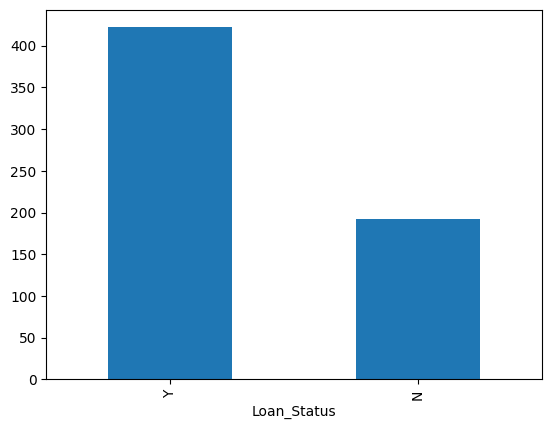

In [15]:
train['Loan_Status'].value_counts().plot.bar()

Now lets visualize each variable separately.

1. **Categorical features** (`Gender`, `Married`, `Self_Employed`, `Credit_History`,`Loan_Status`)

2. **Ordinal features:** (Dependents, Education, Property_Area)

3. **Numerical features** (ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term)


Lets visualize the categorical and ordinal features first.

## Independent variable (Categorical)

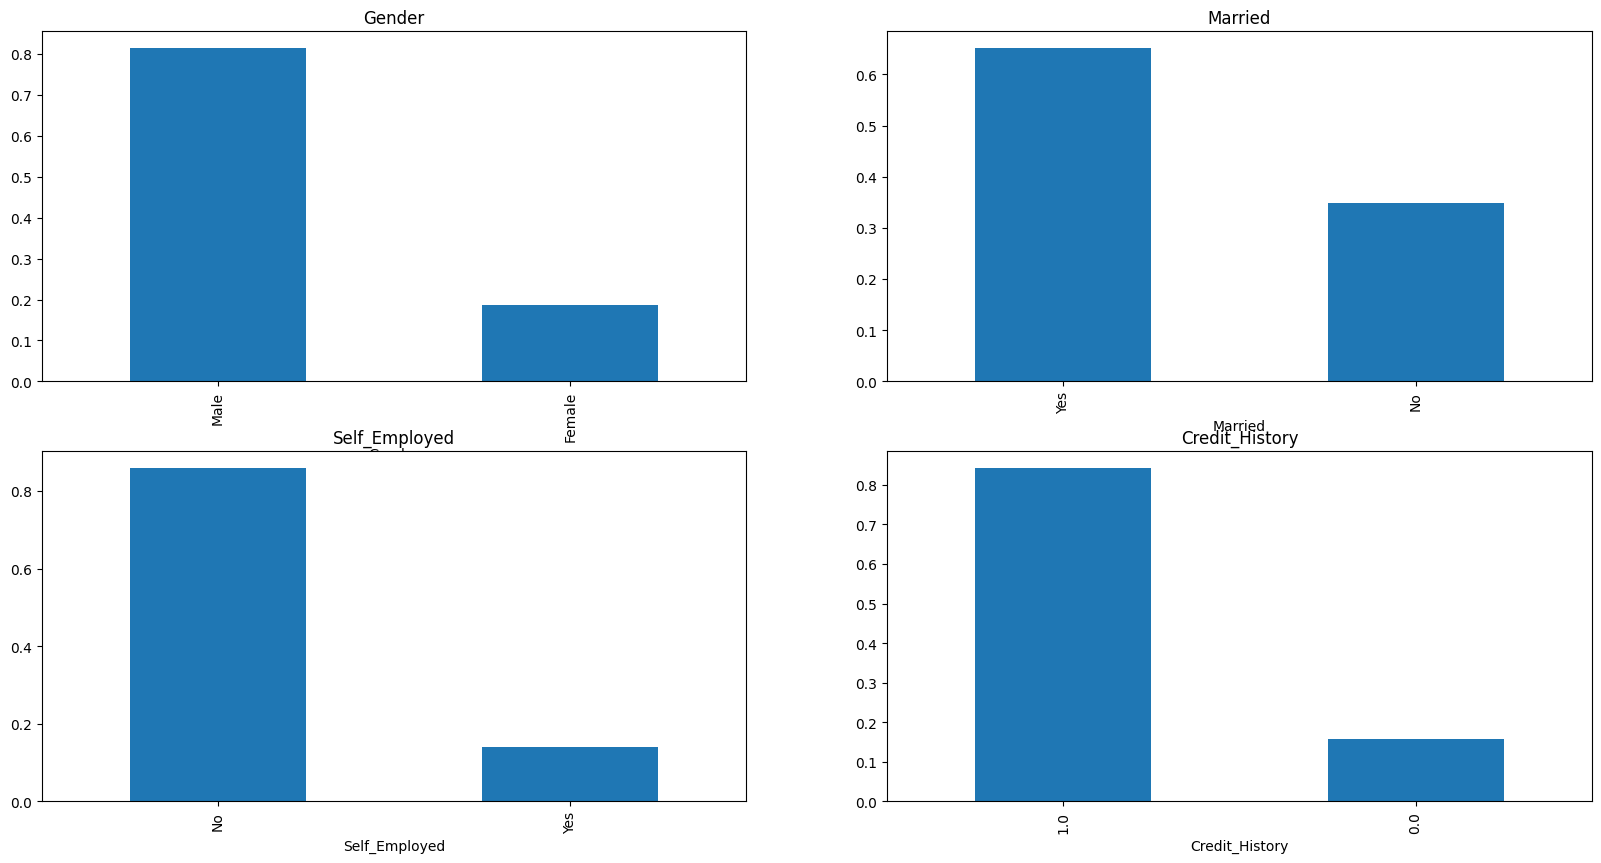

In [16]:
plt.figure(1)
plt.subplot(221) # plt.subplot(nrows, ncols, plot_number)
train['Gender'].value_counts(normalize=True).plot.bar(figsize=(20,10), title= 'Gender')

plt.subplot(222)
train['Married'].value_counts(normalize=True).plot.bar(title= 'Married')

plt.subplot(223)
train['Self_Employed'].value_counts(normalize=True).plot.bar(title= 'Self_Employed')

plt.subplot(224)
train['Credit_History'].value_counts(normalize=True).plot.bar(title= 'Credit_History')

plt.show()

It can be inferred from the above bar plots that:

- 80% applicants in the dataset are male.

- Around 65% of the applicants in the dataset are married.

- Around 15% applicants in the dataset are self employed.

- Around 85% applicants have repaid their debts.

### Independent Variable (Ordinal)

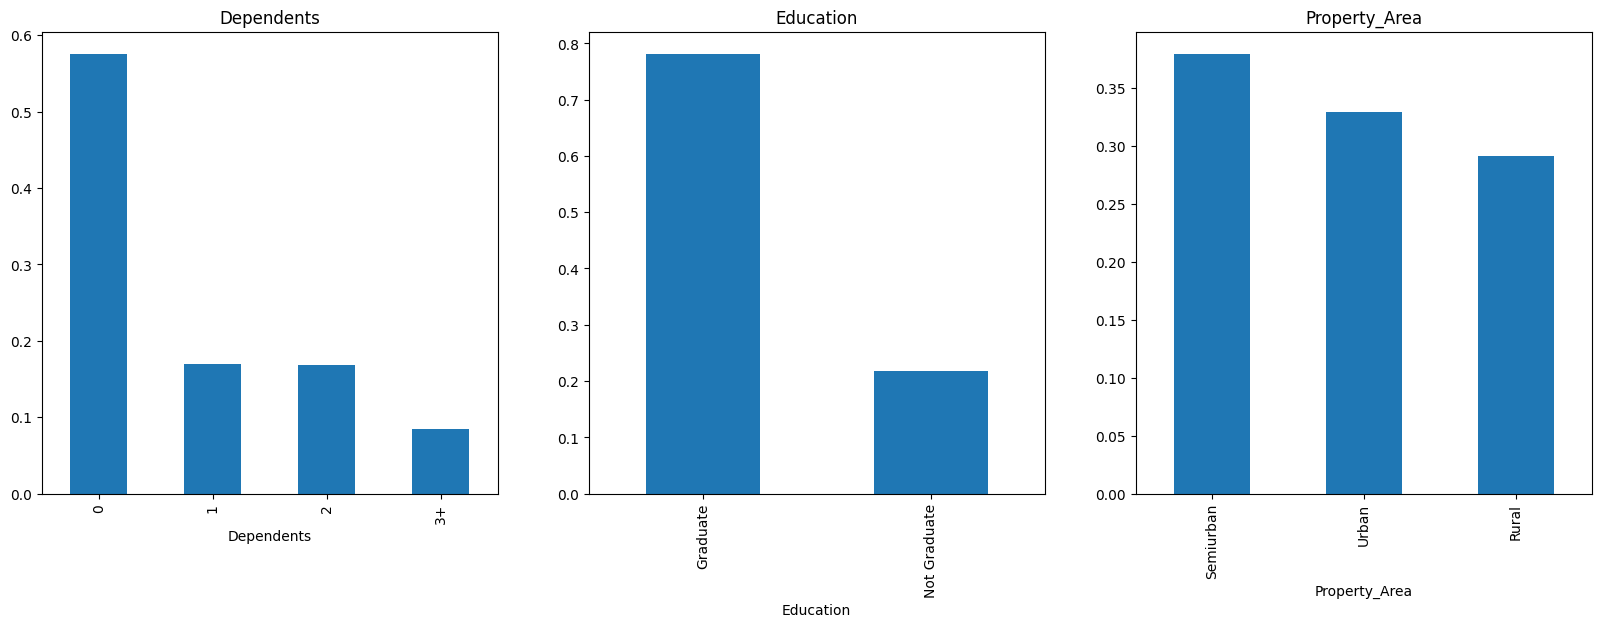

In [17]:
plt.figure(1)
plt.subplot(131)
train['Dependents'].value_counts(normalize=True).plot.bar(figsize = (20,6), title='Dependents')

plt.subplot(132)
train['Education'].value_counts(normalize=True).plot.bar(title= 'Education')

plt.subplot(133)
train['Property_Area'].value_counts(normalize=True).plot.bar(title= 'Property_Area')

plt.show()

## Independent variable (Numerical)

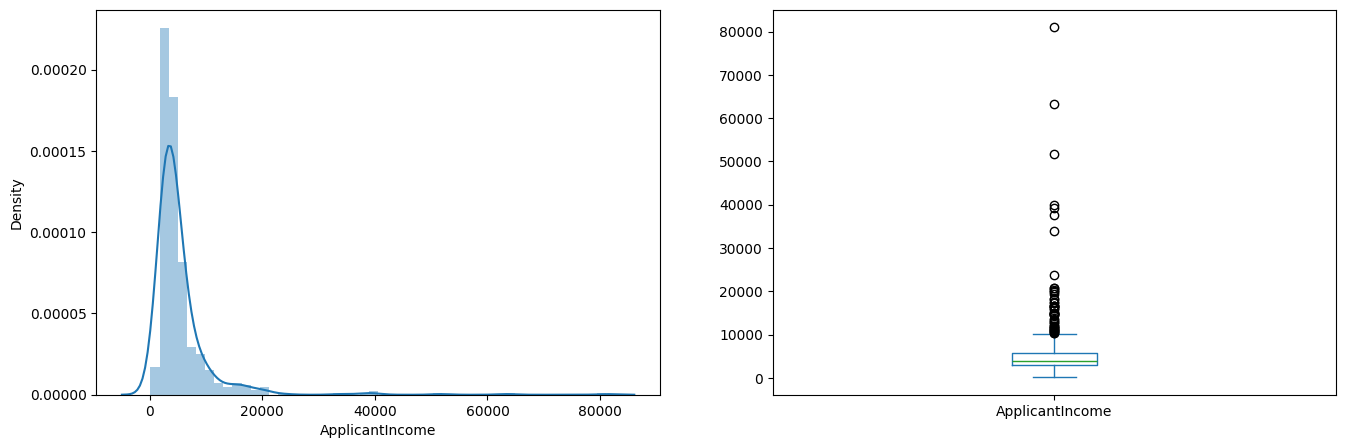

In [18]:
plt.figure(1)
plt.subplot(121)
sns.distplot(train['ApplicantIncome'])

plt.subplot(122)
train['ApplicantIncome'].plot.box(figsize=(16,5))

plt.show()

- Applicant income is not normally distributed. We should make it normal as algorithm works better if the data is normally distributed.

- Boxplot confirms the presence of outliers/extreme values. This can be attributed to the income disparity in the society.
- Lets segregate them by Education

Text(0.5, 0.98, '')

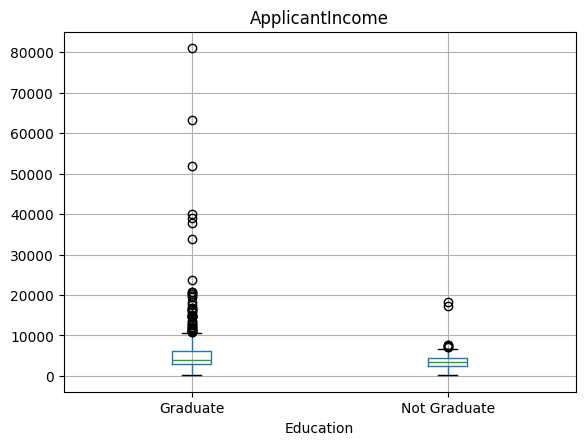

In [19]:
train.boxplot(column="ApplicantIncome", by = "Education")
plt.suptitle("")

 - There are more graduates with very high incomes compared to non-graduates, and these high-income values are represented as outliers.

 - This indicates that some graduates earn significantly more than the typical range, which skews their distribution.

- Lets look at the coapplicant income distribution.

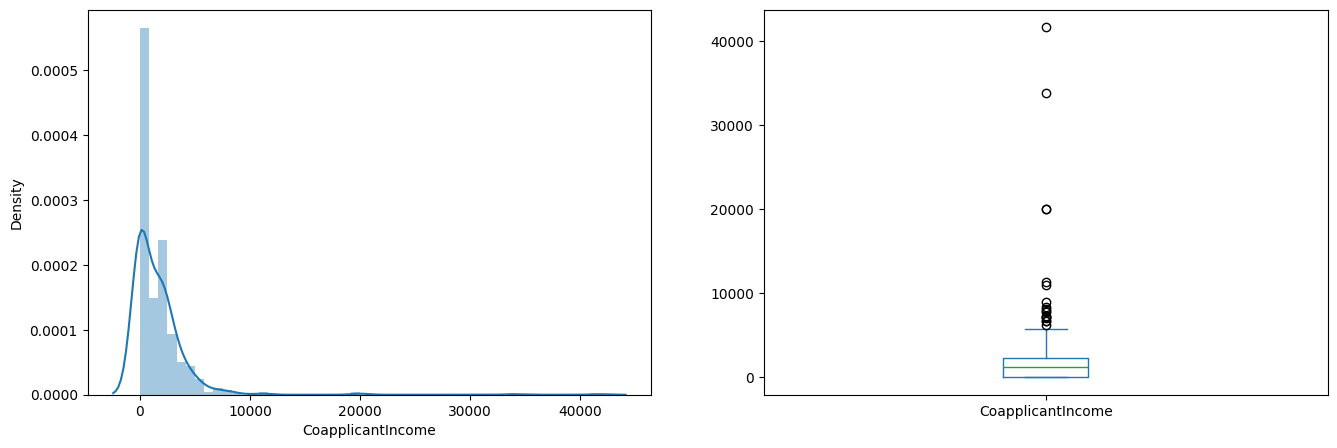

In [20]:
plt.figure(1)
plt.subplot(121)
sns.distplot(train['CoapplicantIncome'])
plt.subplot(122)
train['CoapplicantIncome'].plot.box(figsize=(16,5))
plt.show()

Coapplicants income is not normally distributed.

Lets look at distribution of loan amount

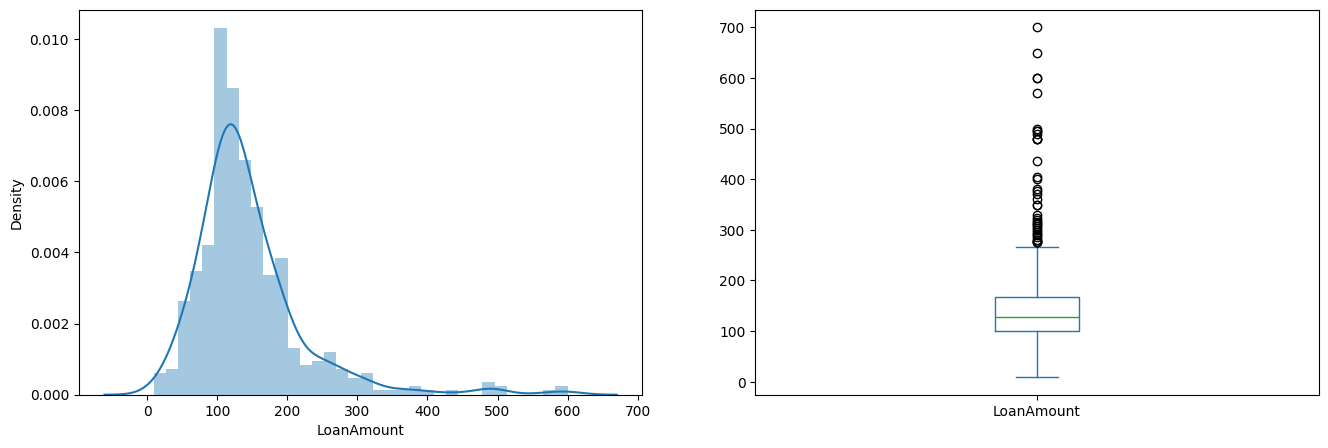

In [21]:
plt.figure(1)
plt.subplot(121)
df = train.dropna()
sns.distplot(df['LoanAmount'])

plt.subplot(122)
train['LoanAmount'].plot.box(figsize=(16,5))

plt.show()

Distribution is fairly normal. Lot of outliers

Now lets check how each feature correlate with Loan Status.

## Bivariate Analysis

## Categorical Independent Variable v/s Target Variable

<Axes: xlabel='Gender'>

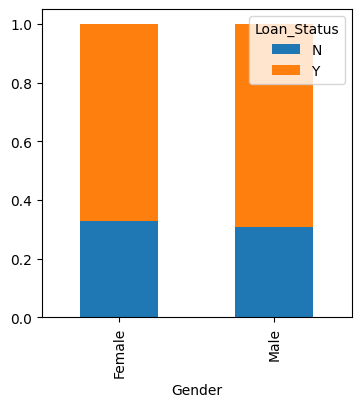

In [22]:
Gender = pd.crosstab(train['Gender'], train['Loan_Status'])
Gender.div(Gender.sum(1).astype(float), axis =0).plot(kind="bar",stacked=True,figsize=(4,4))

Proportion of female and male applicants is more or less same for both approved and unapproved loans.

Now visualize the remaining categorical variables vs target variable.

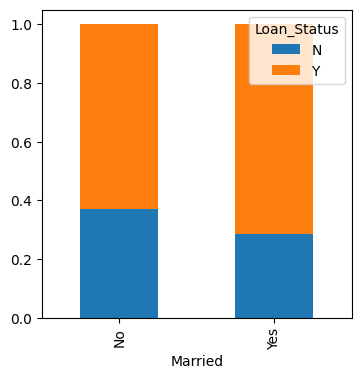

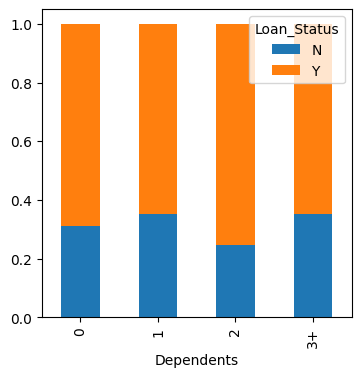

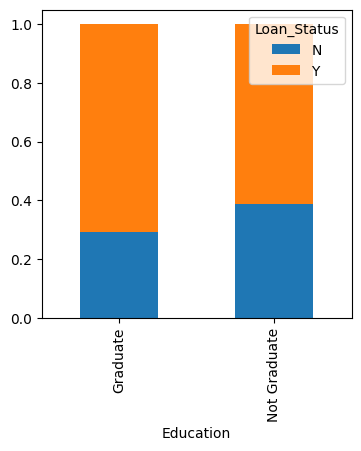

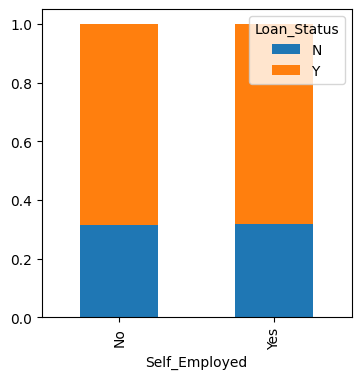

In [23]:
Married = pd.crosstab(train['Married'],train['Loan_Status'])
Dependents = pd.crosstab(train['Dependents'],train['Loan_Status'])
Education = pd.crosstab(train['Education'],train['Loan_Status'])
Self_Employed = pd.crosstab(train['Self_Employed'],train['Loan_Status'])

Married.div(Married.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()
Dependents.div(Dependents.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()
Education.div(Education.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()
Self_Employed.div(Self_Employed.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()

- Proportion of married applicant is higher for the approved loans.
- Distribution of applicant with 1 or 3+ dependets is similar accross both the categories of Loan_Status
- There is nothing significant we can infer from Self_Employed vs Loan_Status plot

Relationship between remaining categorical independent variables and Loan_Status

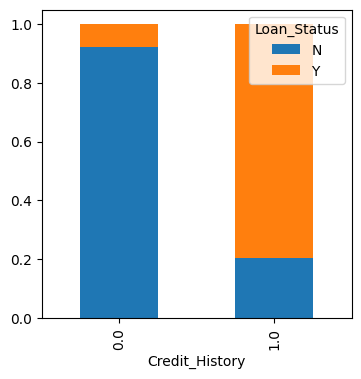

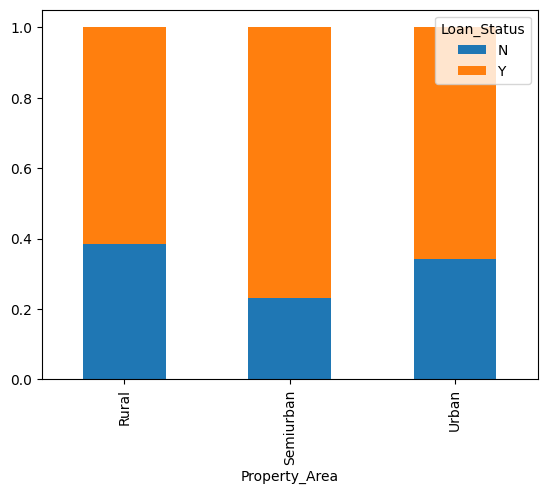

In [24]:
Credit_History = pd.crosstab(train['Credit_History'], train['Loan_Status'])
Property_Area = pd.crosstab(train['Property_Area'], train['Loan_Status'])

Credit_History.div(Credit_History.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True, figsize=(4,4))
plt.show()

Property_Area.div(Property_Area.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)
plt.show()

## Numerical Independent Variable vs Target Variable

We will try to find the mean income of people for which the loan has approved vs mean income of people for which the has not approved.

<Axes: xlabel='Loan_Status'>

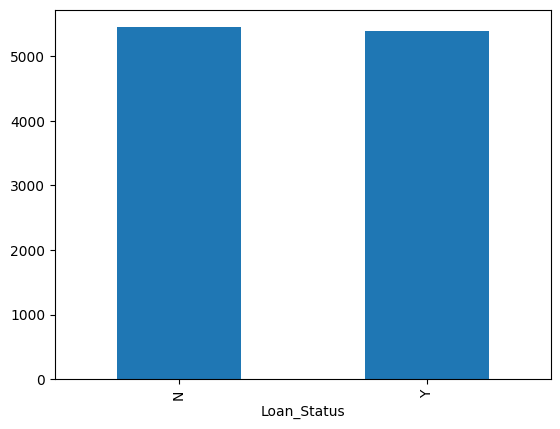

In [25]:
train.groupby('Loan_Status')['ApplicantIncome'].mean().plot.bar()

lets make bins for the applicant income variable based on the values in it and analyze the corresponding loan status for each bin

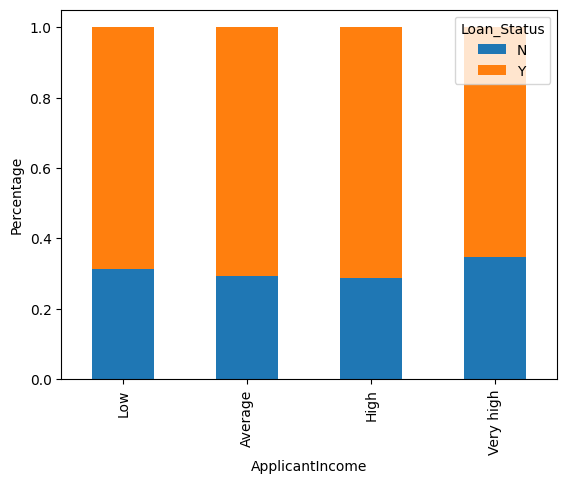

In [26]:
bins=[0,2500,4000,6000,81000]
group=['Low','Average','High', 'Very high']


train['Income_bin']=pd.cut(df['ApplicantIncome'],bins,labels=group)

Income_bin=pd.crosstab(train['Income_bin'],train['Loan_Status'])

Income_bin.div(Income_bin.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)

plt.xlabel('ApplicantIncome')
P = plt.ylabel('Percentage')

analyze the coapplicant income and loan amount variable

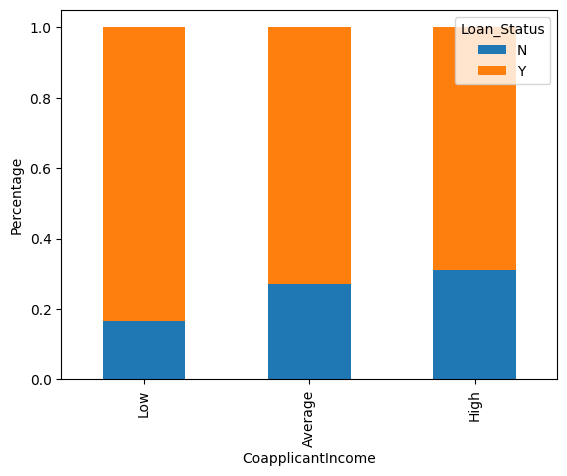

In [27]:
bins = [0,1000,3000,42000]
group = ['Low', 'Average', 'High']

train['Coapplicant_Income_bin'] = pd.cut(df['CoapplicantIncome'],bins,labels=group)

Coapplicant_Income_bin=pd.crosstab(train['Coapplicant_Income_bin'],train['Loan_Status'])
Coapplicant_Income_bin.div(Coapplicant_Income_bin.sum(1).astype(float), axis=0).plot(kind='bar',stacked=True)

plt.xlabel('CoapplicantIncome')
P = plt.ylabel('Percentage')

It shows that coapplicants income is less the chances of loan approval are high. Let us combine the Applicant Income and Coapplicant Income and see the combined effect of Total_Income on the Loan_Status.

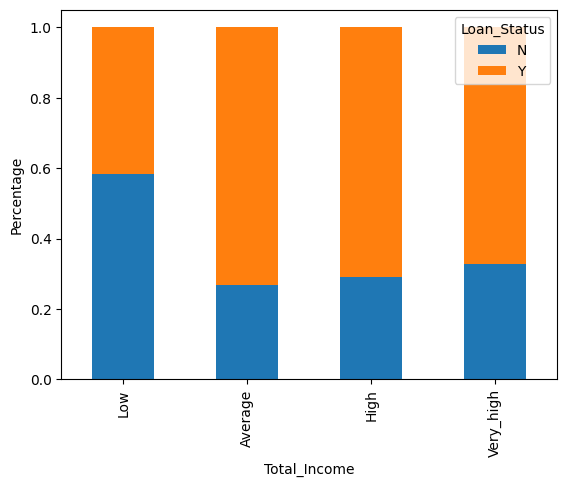

In [28]:
train['Total_Income'] = train['ApplicantIncome'] + train['CoapplicantIncome']

bins = [0,2500,4000,6000,81000]
group = ['Low', 'Average', 'High', 'Very_high']

train['Total_Income_bin']=pd.cut(train['Total_Income'],bins,labels=group)

Total_Income_bin=pd.crosstab(train['Total_Income_bin'],train['Loan_Status'])
Total_Income_bin.div(Total_Income_bin.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)

plt.xlabel('Total_Income')
P = plt.ylabel('Percentage')

We can see that Proportion of loans getting approved for applicants having low Total_Income is very less as compared to that of applicants with Average, High and Very High Income.

Let’s visualize the Loan amount variable.

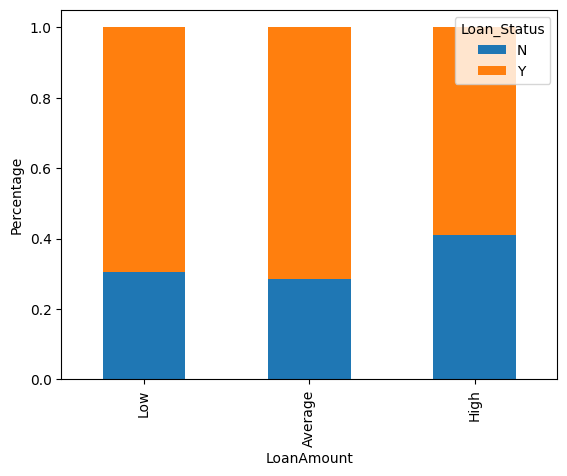

In [29]:
bins=[0,100,200,700]
group=['Low','Average','High']

train['LoanAmount_bin']=pd.cut(df['LoanAmount'],bins,labels=group)

LoanAmount_bin=pd.crosstab(train['LoanAmount_bin'],train['Loan_Status'])
LoanAmount_bin.div(LoanAmount_bin.sum(1).astype(float), axis=0).plot(kind="bar", stacked=True)

plt.xlabel('LoanAmount')
P = plt.ylabel('Percentage')

<Axes: xlabel='Property_Area', ylabel='LoanAmount'>

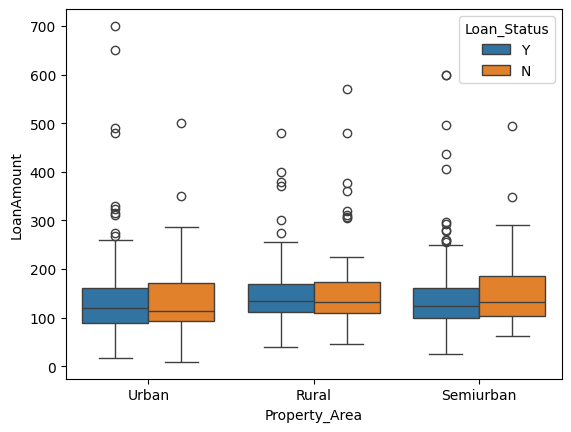

In [30]:
# loan amount vs property area
sns.boxplot(x='Property_Area', y='LoanAmount', hue='Loan_Status', data=train)

<Axes: xlabel='Property_Area', ylabel='ApplicantIncome'>

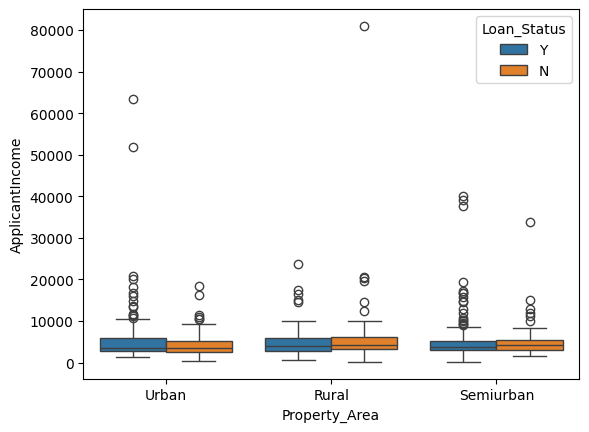

In [31]:
# income vs property area
sns.boxplot(x='Property_Area', y='ApplicantIncome', hue='Loan_Status', data=train)

<Axes: xlabel='Credit_History'>

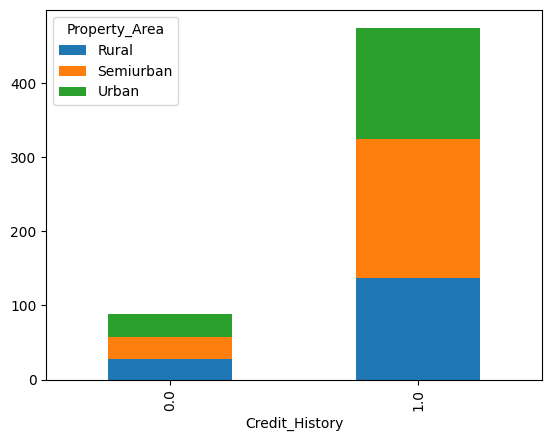

In [32]:
# credit history vs property area bar plot
pd.crosstab(train['Credit_History'], train['Property_Area']).plot(kind='bar',stacked=True)

In [33]:
train.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income_bin,Coapplicant_Income_bin,Total_Income,Total_Income_bin,LoanAmount_bin
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,NaN,NaN,5849.0,High,NaN
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,High,Average,6091.0,Very_high,Average
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,Average,NaN,3000.0,Average,Low
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,Average,Average,4941.0,High,Average
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,High,NaN,6000.0,High,Average


In [34]:
train = train.drop(['Income_bin', 'Coapplicant_Income_bin', 'LoanAmount_bin', 'Total_Income'], axis=1)

In [35]:
train['Dependents'].replace('3+', 3,inplace=True)
test['Dependents'].replace('3+', 3,inplace=True)
train['Loan_Status'].replace('N', 0,inplace=True)
train['Loan_Status'].replace('Y', 1,inplace=True)

Now lets look at the correlation between all the numerical variables. We will use the heat map to visualize the correlation. Heatmaps visualize data through variations in coloring. The variables with darker color means their correlation is more.


In [36]:
numerical_df = train.select_dtypes(include=['int64', 'float64'])

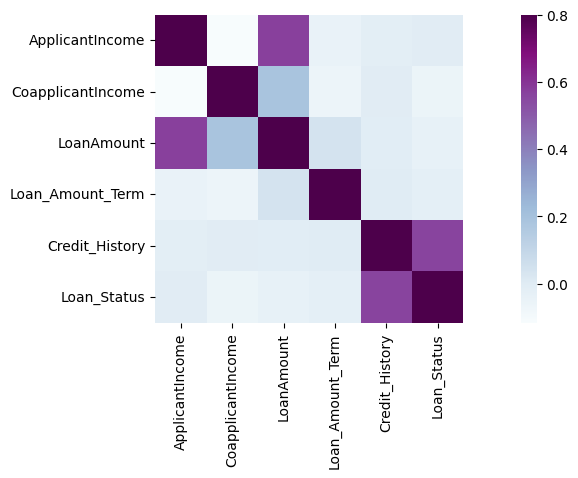

In [37]:
matrix = numerical_df.corr()
f, ax = plt.subplots(figsize=(15,4))
sns.heatmap(matrix, vmax=.8, square=True, cmap="BuPu");

# Missing value Imputation

Lets list out feature wise count of missing values

In [38]:
train.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


There are missing values in Gender, Married, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term and Credit_History features.

- For **numerical** variables : imputation using **mean or median** to avoid irrelevant results.
- For **categorical** variables : imputation using **mode** for irrelevant results.

There are very less missing values in Gender, Married, Dependents, Credit_History and Self_Employed features so we can fill them using the mode of the features.

In [39]:
test.isna().sum()

,0
Loan_ID,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


In [40]:
train['Gender'].fillna(train['Gender'].mode()[0], inplace=True)
train['Married'].fillna(train['Married'].mode()[0], inplace=True)
train['Dependents'].fillna(train['Dependents'].mode()[0], inplace=True)
train['Self_Employed'].fillna(train['Self_Employed'].mode()[0], inplace=True)
train['Credit_History'].fillna(train['Credit_History'].mode()[0], inplace=True)

Now let’s try to find a way to fill the missing values in Loan_Amount_Term. We will look at the value count of the Loan amount term variable.

In [41]:
train['Loan_Amount_Term'].value_counts()

,count
Loan_Amount_Term,
360.0,512
180.0,44
480.0,15
300.0,13
84.0,4
240.0,4
120.0,3
60.0,2
36.0,2


It can be seen that in loan amount term variable, the value of 360 is repeating the most. So we will replace the missing values in this variable using the mode of this variable.

In [42]:
train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0], inplace = True)

Now we will see the LoanAmount variable. As it is a numerical variable, we can use mean or median to impute the missing values. We will use median to fill the null values as earlier we saw that loan amount have outliers so the mean will not be the proper approach as it is highly affected by the presence of outliers.

In [43]:
train['LoanAmount'].fillna(train['LoanAmount'].median(), inplace=True)

Now lets check weather all the missing values are filled in the dataset.

In [44]:
train.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


As we can see that all the missing values have been filled in the train dataset. Let’s fill all the missing values in the test dataset too with the same approach.

In [45]:
test['Gender'].fillna(train['Gender'].mode()[0], inplace=True)
test['Dependents'].fillna(train['Dependents'].mode()[0], inplace=True)
test['Self_Employed'].fillna(train['Self_Employed'].mode()[0], inplace=True)
test['Credit_History'].fillna(train['Credit_History'].mode()[0], inplace=True)
test['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0], inplace=True)
test['LoanAmount'].fillna(train['LoanAmount'].median(), inplace=True)

# Outlier Treatment

Due to these outliers bulk of the data in the loan amount is at the left and the right tail is longer. This is called right skewness. One way to remove the skewness is by doing the log transformation. As we take the log transformation, it does not affect the smaller values much, but reduces the larger values. So, we get a distribution similar to normal distribution.

Let’s visualize the effect of log transformation. We will do the similar changes to the test file simultaneously.

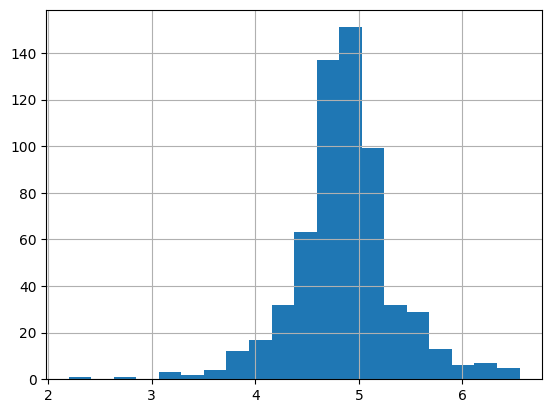

In [46]:
train['LoanAmount_log'] = np.log(train['LoanAmount'])
train['LoanAmount_log'].hist(bins=20)
test['LoanAmount_log'] = np.log(test['LoanAmount'])

Now the distribution looks much closer to normal and effect of extreme values has been significantly subsided.


# Base Feature Engineering

Set `Loan ID` column as index.

In [47]:
train.set_index('Loan_ID',inplace=True)
test.set_index('Loan_ID',inplace=True)

In [48]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income_bin,LoanAmount_log
Loan_ID,,,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1,High,4.852030
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0,Very_high,4.852030
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1,Average,4.189655
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1,High,4.787492
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1,High,4.948760


In [49]:
# drop the features
train.drop(['Total_Income_bin','LoanAmount_log'],axis=1,inplace=True)
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [50]:
test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,LoanAmount_log
Loan_ID,,,,,,,,,,,,
LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban,4.700480
LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban,4.836282
LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban,5.337538
LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,1.0,Urban,4.605170
LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban,4.356709


In [51]:
test.drop(['LoanAmount_log'],axis=1,inplace=True)
test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_ID,,,,,,,,,,,
LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,1.0,Urban
LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [52]:
print(train.columns)
print(test.columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')
Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')


## Categorical Feature Encoding
Based on the features we will perform different encoding
1. Binary Encoding
2. One-Hot-Encoding
3. Label Encoding

## Binary Encoding
`Binary encode` columns with two unique values (Gender, Married, Education, Self_Employed):

In [53]:
# binary encoding on train data
train['Gender'] = train['Gender'].map({'Male': 1, 'Female': 0})
train['Married'] = train['Married'].map({'Yes': 1, 'No': 0})
train['Education'] = train['Education'].map({'Graduate': 1, 'Not Graduate': 0})
train['Self_Employed'] = train['Self_Employed'].map({'Yes': 1, 'No': 0})

In [54]:
# binary encoding on test data
test['Gender'] = test['Gender'].map({'Male': 1, 'Female': 0})
test['Married'] = test['Married'].map({'Yes': 1, 'No': 0})
test['Education'] = test['Education'].map({'Graduate': 1, 'Not Graduate': 0})
test['Self_Employed'] = test['Self_Employed'].map({'Yes': 1, 'No': 0})

Handling `Dependents`

In [55]:
# train data
train['Dependents'] = train['Dependents'].replace('3+', 3).astype(int)

In [56]:
# test data
test['Dependents'] = test['Dependents'].replace('3+', 3).astype(int)

## One-hot-encoding

In [57]:
# train data
train_df_encoded = pd.get_dummies(train, columns=['Property_Area'], drop_first=True)
train_df_encoded.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
Loan_ID,,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,False,True
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,False,False
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,False,True
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,False,True
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,False,True


In [58]:
# test data
test_df_encoded = pd.get_dummies(test, columns=['Property_Area'], drop_first=True)
test_df_encoded.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Semiurban,Property_Area_Urban
Loan_ID,,,,,,,,,,,,
LP001015,1,1,0,1,0,5720,0,110.0,360.0,1.0,False,True
LP001022,1,1,1,1,0,3076,1500,126.0,360.0,1.0,False,True
LP001031,1,1,2,1,0,5000,1800,208.0,360.0,1.0,False,True
LP001035,1,1,2,1,0,2340,2546,100.0,360.0,1.0,False,True
LP001051,1,0,0,0,0,3276,0,78.0,360.0,1.0,False,True


In [59]:
# train df
train_df_encoded = train_df_encoded.astype(int)
train_df_encoded.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
Loan_ID,,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0,128,360,1,1,0,1
LP001003,1,1,1,1,0,4583,1508,128,360,1,0,0,0
LP001005,1,1,0,1,1,3000,0,66,360,1,1,0,1
LP001006,1,1,0,0,0,2583,2358,120,360,1,1,0,1
LP001008,1,0,0,1,0,6000,0,141,360,1,1,0,1


In [60]:
# train df
test_df_encoded = test_df_encoded.astype(int)
test_df_encoded.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Semiurban,Property_Area_Urban
Loan_ID,,,,,,,,,,,,
LP001015,1,1,0,1,0,5720,0,110,360,1,0,1
LP001022,1,1,1,1,0,3076,1500,126,360,1,0,1
LP001031,1,1,2,1,0,5000,1800,208,360,1,0,1
LP001035,1,1,2,1,0,2340,2546,100,360,1,0,1
LP001051,1,0,0,0,0,3276,0,78,360,1,0,1


## Label Encoding

In [61]:
# lable encoding on property area column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# train data label encoding
train['Property_Area'] = le.fit_transform(train['Property_Area'])
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1


In [62]:
# train data label encoding
test['Property_Area'] = le.fit_transform(test['Property_Area'])
test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_ID,,,,,,,,,,,
LP001015,1,1,0,1,0,5720,0,110.0,360.0,1.0,2
LP001022,1,1,1,1,0,3076,1500,126.0,360.0,1.0,2
LP001031,1,1,2,1,0,5000,1800,208.0,360.0,1.0,2
LP001035,1,1,2,1,0,2340,2546,100.0,360.0,1.0,2
LP001051,1,0,0,0,0,3276,0,78.0,360.0,1.0,2


# Building Model

## Split data into X and y (Using Label Encoded Data)

In [63]:
X = train.drop('Loan_Status', axis=1)
y = train['Loan_Status']

In [64]:
X

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_ID,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,2
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...
LP002978,0,0,0,1,0,2900,0.0,71.0,360.0,1.0,0
LP002979,1,1,3,1,0,4106,0.0,40.0,180.0,1.0,0
LP002983,1,1,1,1,0,8072,240.0,253.0,360.0,1.0,2


In [65]:
y

,Loan_Status
Loan_ID,
LP001002,1
LP001003,0
LP001005,1
LP001006,1
LP001008,1
...,...
LP002978,1
LP002979,1
LP002983,1


## Train Test Split

In [66]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
# shape
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(491, 11)
(123, 11)
(491,)
(123,)


## Building KNN Model

In [68]:
# build KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [69]:
# training score
print("KNN train Score: ",knn.score(X_train, y_train))
print("KNN test Score: ",knn.score(X_test, y_test))

KNN train Score:  0.7352342158859471
KNN test Score:  0.5772357723577236


In [70]:
# evaluate for k values
scores = []
for k in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))
scores

[0.5853658536585366,
 0.5528455284552846,
 0.6178861788617886,
 0.5609756097560976,
 0.5772357723577236,
 0.5691056910569106,
 0.5853658536585366,
 0.5853658536585366,
 0.5772357723577236,
 0.5609756097560976,
 0.6016260162601627,
 0.5853658536585366,
 0.5934959349593496,
 0.5853658536585366,
 0.6097560975609756,
 0.6178861788617886,
 0.6260162601626016,
 0.6341463414634146,
 0.6178861788617886,
 0.6178861788617886,
 0.6504065040650406,
 0.6260162601626016,
 0.6260162601626016,
 0.6260162601626016,
 0.6666666666666666,
 0.6504065040650406,
 0.6504065040650406,
 0.6422764227642277,
 0.6504065040650406,
 0.6504065040650406,
 0.6504065040650406,
 0.6504065040650406,
 0.6504065040650406,
 0.6585365853658537,
 0.6504065040650406,
 0.6585365853658537,
 0.6504065040650406,
 0.6504065040650406,
 0.6504065040650406]

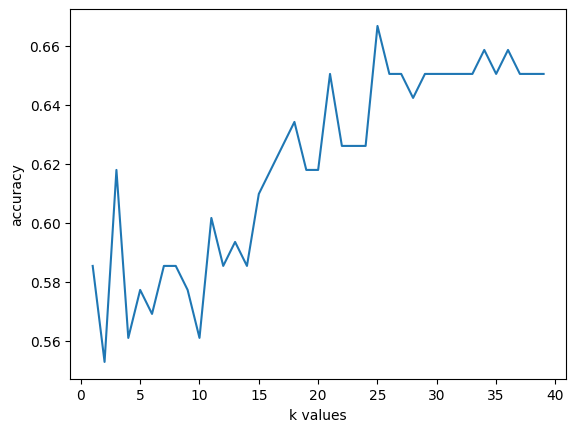

In [71]:
# graph for k values
plt.plot(range(1, 40), scores)
plt.xlabel('k values')
plt.ylabel('accuracy')
plt.show()

In [72]:
# retrain knn on k = 25
knn = KNeighborsClassifier(n_neighbors=25)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=25)

In [73]:
#score
print("KNN train Score: ",knn.score(X_train, y_train))
print("KNN test Score: ",knn.score(X_test, y_test))

KNN train Score:  0.7087576374745418
KNN test Score:  0.6666666666666666


In [74]:
# accuracy
from sklearn.metrics import accuracy_score
y_pred = knn.predict(X_test)
KNN_accuracy = accuracy_score(y_test, y_pred)
KNN_accuracy

0.6666666666666666

In [75]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.05      0.09        43
           1       0.66      1.00      0.80        80

    accuracy                           0.67       123
   macro avg       0.83      0.52      0.44       123
weighted avg       0.78      0.67      0.55       123



## Building SVM Model

In [76]:
# build SVM
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

SVC(kernel='linear')

In [77]:
# score
print("SVM train Score: ",svm.score(X_train, y_train))
print("SVM train Score: ",svm.score(X_test, y_test))

SVM train Score:  0.7963340122199593
SVM train Score:  0.7886178861788617


In [78]:
# accuracy
y_pred = svm.predict(X_test)
SVM_accuracy = accuracy_score(y_test, y_pred)
print("SVM Accuracy: ",SVM_accuracy)

SVM Accuracy:  0.7886178861788617


In [79]:
#classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.40      0.57        43
           1       0.75      1.00      0.86        80

    accuracy                           0.79       123
   macro avg       0.88      0.70      0.71       123
weighted avg       0.84      0.79      0.76       123



## Building Decision Tree

In [80]:
#build decision tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy', max_depth=3)
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [81]:
#accuracy
y_pred = dt.predict(X_test)
DT_accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy: ",DT_accuracy)

Decision Tree Accuracy:  0.7886178861788617


In [82]:
#classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



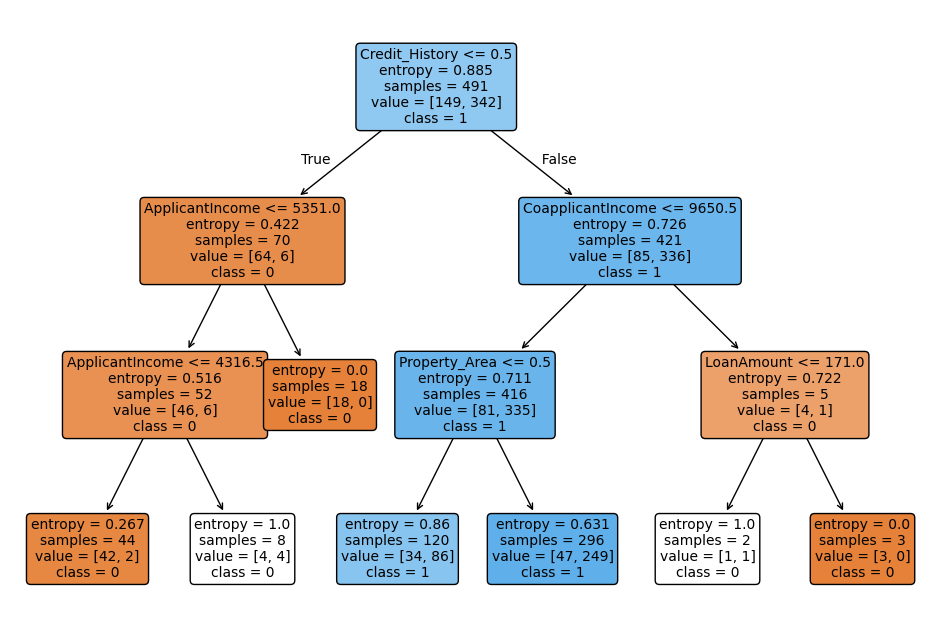

In [83]:
# visualize decision tree
from sklearn.tree import plot_tree

# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(dt,
          feature_names=X.columns,
          class_names=['0', '1'],
          filled=True,
          rounded=True,
          fontsize=10
          )
plt.show()

# Model performace on Test data

In [84]:
# Predict on the test dataset knn
test_predictions_knn = knn.predict(test)

# Save predictions to csv file
output = pd.DataFrame({'Loan_ID': test_original['Loan_ID'], 'Loan_Status': test_predictions_knn})
output.to_csv("test_predictions_knn.csv", index=False)

In [85]:
# Predict on the test dataset svm
test_predictions_svm = svm.predict(test)

# Save predictions to csv file
output = pd.DataFrame({'Loan_ID': test_original['Loan_ID'], 'Loan_Status': test_predictions_svm})
output.to_csv("test_predictions_svm.csv", index=False)

In [86]:
# Predict on the test dataset knn
test_predictions_dt = dt.predict(test)

# Saving predictions to csv file
output = pd.DataFrame({'Loan_ID': test_original['Loan_ID'], 'Loan_Status': test_predictions_dt})
output.to_csv("test_predictions_dt.csv", index=False)

# Model Comparison

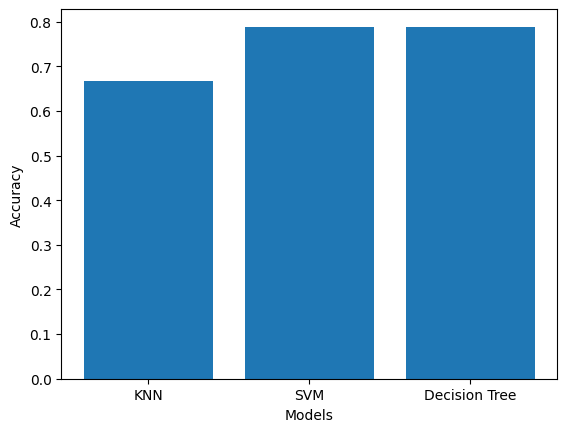

In [87]:
# bar plot for comaring model results
models = ['KNN', 'SVM', 'Decision Tree']
accuracy = [KNN_accuracy, SVM_accuracy, DT_accuracy]
plt.bar(models, accuracy)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.show()

# Final Feature Engineering

1. Outlier treatment (Applicant Income, Loan Amount, Coapplicant income)
2. Perform Feature Importance.

## 1. Outlier Treatment (ApplicationIncome, LoanAmount, CoapplicantIncome)

In [88]:
train['ApplicantIncome_log'] = np.log(train['ApplicantIncome'])
train['LoanAmount_log'] = np.log(train['LoanAmount'])

In [ ]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_log,LoanAmount_log
Loan_ID,,,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1,8.674026,4.852030
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,8.430109,4.852030
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1,8.006368,4.189655
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1,7.856707,4.787492
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1,8.699515,4.948760


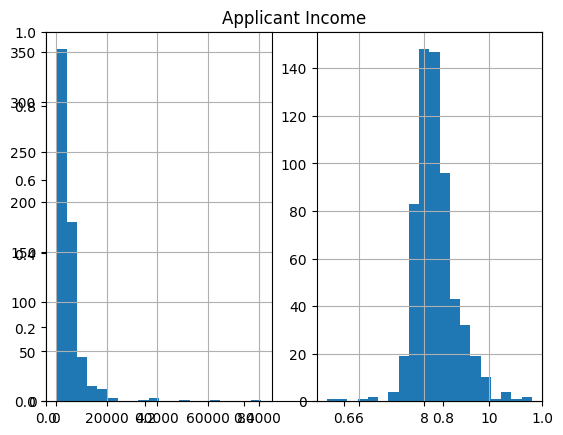

In [89]:
plt.figure(1)
plt.title("Applicant Income")

plt.subplot(121)
train['ApplicantIncome'].hist(bins=20)

plt.subplot(122)
train['ApplicantIncome_log'].hist(bins=20)

plt.show()

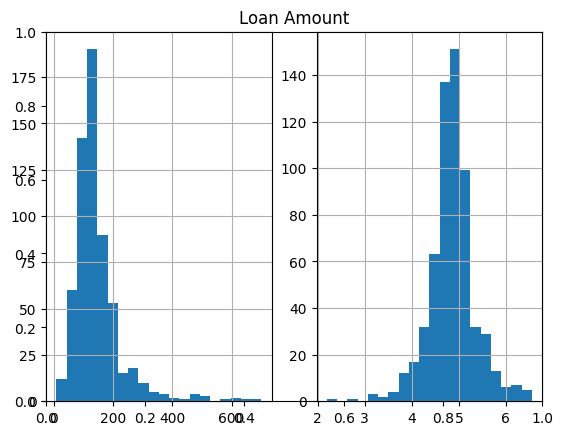

In [90]:
plt.figure(1)
plt.title("Loan Amount")

plt.subplot(121)
train['LoanAmount'].hist(bins=20)

plt.subplot(122)
train['LoanAmount_log'].hist(bins=20)

plt.show()

In [91]:
train['CoapplicantIncome_log_offset'] = np.log(train['CoapplicantIncome'] + 1)

In [92]:
# sqrt on coapplicant
train['CoapplicantIncome_log'] = np.sqrt(train['CoapplicantIncome'])

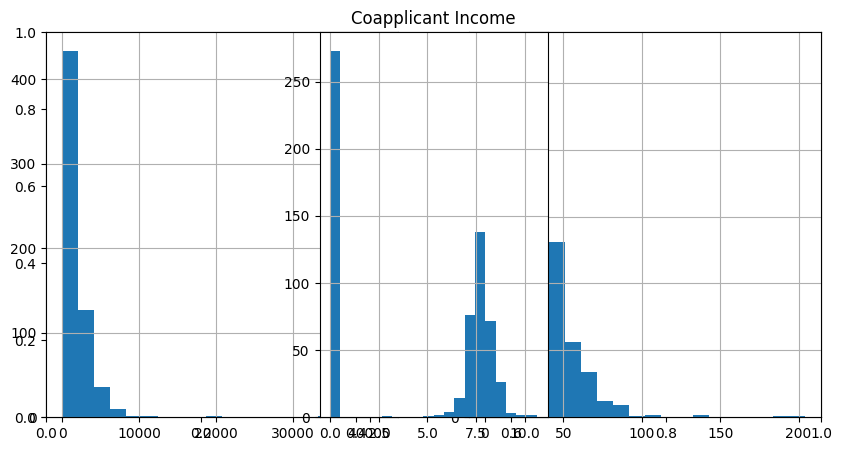

In [93]:
plt.figure(figsize = (10,5))
plt.title("Coapplicant Income")

plt.subplot(121)
train['CoapplicantIncome'].hist(bins=20)

plt.subplot(122)
train['CoapplicantIncome_log'].hist(bins=20)

plt.subplot(132)
train['CoapplicantIncome_log_offset'].hist(bins=20)

plt.show()

In [94]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_log_offset,CoapplicantIncome_log
Loan_ID,,,,,,,,,,,,,,,,
LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1,8.674026,4.852030,0.000000,0.000000
LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,8.430109,4.852030,7.319202,38.832976
LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1,8.006368,4.189655,0.000000,0.000000
LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1,7.856707,4.787492,7.765993,48.559242
LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1,8.699515,4.948760,0.000000,0.000000


In [95]:
train.drop(['ApplicantIncome','LoanAmount','CoapplicantIncome_log_offset','CoapplicantIncome'],axis=1,inplace=True)

In [96]:
train.head()

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_log
Loan_ID,,,,,,,,,,,,
LP001002,1,0,0,1,0,360.0,1.0,2,1,8.674026,4.852030,0.000000
LP001003,1,1,1,1,0,360.0,1.0,0,0,8.430109,4.852030,38.832976
LP001005,1,1,0,1,1,360.0,1.0,2,1,8.006368,4.189655,0.000000
LP001006,1,1,0,0,0,360.0,1.0,2,1,7.856707,4.787492,48.559242
LP001008,1,0,0,1,0,360.0,1.0,2,1,8.699515,4.948760,0.000000


In [97]:
test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Loan_ID,,,,,,,,,,,
LP001015,1,1,0,1,0,5720,0,110.0,360.0,1.0,2
LP001022,1,1,1,1,0,3076,1500,126.0,360.0,1.0,2
LP001031,1,1,2,1,0,5000,1800,208.0,360.0,1.0,2
LP001035,1,1,2,1,0,2340,2546,100.0,360.0,1.0,2
LP001051,1,0,0,0,0,3276,0,78.0,360.0,1.0,2


In [98]:
test['ApplicantIncome_log'] = np.log(test['ApplicantIncome'])
test['LoanAmount_log'] = np.log(test['LoanAmount'])
test['CoapplicantIncome_log'] = np.sqrt(test['CoapplicantIncome'])

test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,ApplicantIncome_log,LoanAmount_log,CoapplicantIncome_log
Loan_ID,,,,,,,,,,,,,,
LP001015,1,1,0,1,0,5720,0,110.0,360.0,1.0,2,8.651724,4.700480,0.000000
LP001022,1,1,1,1,0,3076,1500,126.0,360.0,1.0,2,8.031385,4.836282,38.729833
LP001031,1,1,2,1,0,5000,1800,208.0,360.0,1.0,2,8.517193,5.337538,42.426407
LP001035,1,1,2,1,0,2340,2546,100.0,360.0,1.0,2,7.757906,4.605170,50.457903
LP001051,1,0,0,0,0,3276,0,78.0,360.0,1.0,2,8.094378,4.356709,0.000000


In [99]:
test.drop(['ApplicantIncome','LoanAmount','CoapplicantIncome'],axis=1,inplace=True)

In [100]:
test.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'ApplicantIncome_log', 'LoanAmount_log', 'CoapplicantIncome_log'],
      dtype='object')

In [101]:
train.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'ApplicantIncome_log', 'LoanAmount_log', 'CoapplicantIncome_log'],
      dtype='object')

## Base Model

In [102]:
# split data
X = train.drop('Loan_Status', axis=1)
y = train['Loan_Status']

In [103]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [104]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(491, 11)
(123, 11)
(491,)
(123,)


In [105]:
# build Decision tree
dt = DecisionTreeClassifier(criterion='entropy', max_depth=3)
dt.fit(X_train, y_train)

#baseline score
y_pred = dt.predict(X_test)
DT_accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy: ",DT_accuracy)

Decision Tree Accuracy:  0.7886178861788617


In [106]:
#build SVM
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

#baseline score
y_pred = svm.predict(X_test)
SVM_accuracy = accuracy_score(y_test, y_pred)
print("SVM Accuracy: ",SVM_accuracy)

SVM Accuracy:  0.7886178861788617


## Feature Importance : LOFO

In [107]:
feature_importance = {}

for feature in X.columns:

    # Drop one feature
    X_train_reduced = X_train.drop(columns=[feature])
    X_test_reduced = X_test.drop(columns=[feature])

    # Train and evaluate the model
    dt.fit(X_train_reduced, y_train)
    y_pred_reduced = dt.predict(X_test_reduced)

    reduced_accuracy = accuracy_score(y_test, y_pred_reduced)

    # Compute the performance drop
    performance_drop = DT_accuracy - reduced_accuracy
    feature_importance[feature] = performance_drop

# rank features by importance
sorted_importance = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

print("\nFeature Importance (LOFO):")
for feature, drop in sorted_importance:
    print(f"{feature}: Performance Drop = {drop:.4f}")


Feature Importance (LOFO):
Credit_History: Performance Drop = 0.1545
Gender: Performance Drop = 0.0000
Married: Performance Drop = 0.0000
Dependents: Performance Drop = 0.0000
Education: Performance Drop = 0.0000
Self_Employed: Performance Drop = 0.0000
Loan_Amount_Term: Performance Drop = 0.0000
Property_Area: Performance Drop = 0.0000
ApplicantIncome_log: Performance Drop = 0.0000
LoanAmount_log: Performance Drop = 0.0000
CoapplicantIncome_log: Performance Drop = 0.0000


In [108]:
feature_importance = {}

for feature in X.columns:

    # Drop one feature
    X_train_reduced = X_train.drop(columns=[feature])
    X_test_reduced = X_test.drop(columns=[feature])

    # Train and evaluate the model
    svm.fit(X_train_reduced, y_train)
    y_pred_reduced = svm.predict(X_test_reduced)

    reduced_accuracy = accuracy_score(y_test, y_pred_reduced)

    # Compute the performance drop
    performance_drop = SVM_accuracy - reduced_accuracy
    feature_importance[feature] = performance_drop

# rank features by importance
sorted_importance = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

print("\nFeature Importance (LOFO):")
for feature, drop in sorted_importance:
    print(f"{feature}: Performance Drop = {drop:.4f}")


Feature Importance (LOFO):
Credit_History: Performance Drop = 0.1382
Gender: Performance Drop = 0.0000
Married: Performance Drop = 0.0000
Dependents: Performance Drop = 0.0000
Education: Performance Drop = 0.0000
Self_Employed: Performance Drop = 0.0000
Loan_Amount_Term: Performance Drop = 0.0000
Property_Area: Performance Drop = 0.0000
ApplicantIncome_log: Performance Drop = 0.0000
LoanAmount_log: Performance Drop = 0.0000
CoapplicantIncome_log: Performance Drop = 0.0000


**Interpretation:**
- Credit_History (Performance Drop = 0.1545):

  1. This feature has the highest performance drop, meaning it is the most critical predictor for the model's accuracy.
  2. Removing this feature significantly impacts the model's ability to make correct predictions.

- Other Features (Performance Drop = 0.0000):

  1. For all other features (Gender, Married, Dependents, Education, etc.), the performance drop is zero.
  2. This suggests that these features do not contribute significantly to the model's predictions. In essence, the model's performance remains unchanged even if these features are excluded.

## Actionable Insights Based on LOFO

- For Positive Values: Retain these features; they are contributing positively.
- For Negative Values: Consider dropping these features, as they may be redundant or harmful to the model.
- For Zero Values: Evaluate whether these features are necessary, as they may not contribute meaningfully.

# Building Final ML model with Hyperparameter Tuning

In [109]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [110]:
train.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'ApplicantIncome_log', 'LoanAmount_log', 'CoapplicantIncome_log'],
      dtype='object')

In [111]:
X = train[['Loan_Amount_Term','Credit_History','ApplicantIncome_log','LoanAmount_log','CoapplicantIncome_log']]
Y = train['Loan_Status']

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [113]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(491, 5)
(123, 5)
(491,)
(123,)


In [114]:
# Train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(criterion='entropy',
                                  random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [115]:
# hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'max_leaf_nodes': [10, 20, 50]
}

In [116]:
# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=dt_model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs = -1, # use all cpu cores
                           verbose = 2 # print progress
                           )

In [117]:
# Fit Grid Search to the training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(criterion='entropy',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10, 15],
                         'max_leaf_nodes': [10, 20, 50],
                         'min_samples_leaf': [1, 5, 10, 20],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy', verbose=2)

In [118]:
# Best parameters found by GridSearchCV
print("Best Hyperparameters from Grid Search:", grid_search.best_params_)

Best Hyperparameters from Grid Search: {'max_depth': 3, 'max_leaf_nodes': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}


In [119]:
# Evaluating the model with the best parameters on the test set
best_dt_model = grid_search.best_estimator_
y_pred = best_dt_model.predict(X_test)

In [120]:
# Predict on training and testing data
train_preds = best_dt_model.predict(X_train)
test_preds = best_dt_model.predict(X_test)

# Calculating accuracy
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.8147
Testing Accuracy: 0.7805


In [121]:
print("Classification Report (Grid Search):")
print(classification_report(y_test, y_pred))

Classification Report (Grid Search):
              precision    recall  f1-score   support

           0       0.86      0.44      0.58        43
           1       0.76      0.96      0.85        80

    accuracy                           0.78       123
   macro avg       0.81      0.70      0.72       123
weighted avg       0.80      0.78      0.76       123



In [122]:
# hyperparameter distribution
from scipy.stats import randint

param_dist = {
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20),
    'max_leaf_nodes': randint(10, 100)
}

In [123]:
# initializing random search
random_search = RandomizedSearchCV(estimator=dt_model,
                                   param_distributions=param_dist,
                                   n_iter=100,  #number of iterations
                                   cv=5,
                                   scoring='accuracy',
                                   n_jobs=-1,
                                   verbose=2
                                  )

In [124]:
# Fitting Random Search to the training data
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5,
                   estimator=DecisionTreeClassifier(criterion='entropy',
                                                    random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7aa88240e120>,
                                        'max_leaf_nodes': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7aa881f610f0>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7aa8834fad50>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7aa8834fa850>},
                   scoring='accuracy', verbose=2)

In [125]:
# Best parameters found by RandomizedSearchCV
print("Best Hyperparameters from Random Search:", random_search.best_params_)

Best Hyperparameters from Random Search: {'max_depth': 11, 'max_leaf_nodes': 89, 'min_samples_leaf': 19, 'min_samples_split': 18}


In [126]:
# Evaluating the model with the best parameters on the test set
best_dt_model_random = random_search.best_estimator_
y_pred_random = best_dt_model_random.predict(X_test)

In [127]:
# Predict on training and testing data
train_preds = best_dt_model_random.predict(X_train)
test_preds = best_dt_model_random.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, y_pred_random)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.8167
Testing Accuracy: 0.7480


In [128]:
print("Classification Report (Random Search):")
print(classification_report(y_test, y_pred_random))

Classification Report (Random Search):
              precision    recall  f1-score   support

           0       0.71      0.47      0.56        43
           1       0.76      0.90      0.82        80

    accuracy                           0.75       123
   macro avg       0.74      0.68      0.69       123
weighted avg       0.74      0.75      0.73       123



## Hyperparameter on SVM

In [ ]:
svm = SVC()

# Defining the hyperparameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Kernel type
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001]  # Kernel coefficient
}

# Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=svm,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           verbose=1)

grid_search.fit(X_train, y_train)

# Best parameters and performance
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Evaluation on test set
svm_model = grid_search.best_estimator_
y_pred = svm_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
